En este cuaderno probaremos diversas normalizaciones junto al modelo basado en Redes neuronales Densas.
Primero cargamos los datos que usaremos.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

import numpy as np
from pathlib import Path

processed_path = Path("../data/splits/2026-08-16_processed_data_no_duplicates.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [2]:
# Datos de Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos de SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

Probamos ahora una normalización basada en la media aritmética de todos los espectros observados en el conjunto de entrenamiento. 

In [3]:
# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm_global = (X_train - X_mean) / X_std
X_val_norm_global = (X_val - X_mean) / X_std
X_test_norm_global = (X_test - X_mean) / X_std

y_train_norm_global = (y_train - y_mean) / y_std
y_val_norm_global = (y_val - y_mean) / y_std
y_test_norm_global = (y_test - y_mean) / y_std

In [4]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

# Definimos la estructura del modelo a usar
model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta = 1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Entrenamos el modelo

In [6]:
history_norm_global = model.fit(
    X_train_norm_global,
    y_train_norm_global,
    validation_data=(X_val_norm_global, y_val_norm_global),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 32s 61ms/step - loss: 0.0680 - mae: 0.2135 - mse: 0.1659 - val_loss: 0.0147 - val_mae: 0.0974 - val_mse: 0.0317 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - loss: 0.0131 - mae: 0.0934 - mse: 0.0277 - val_loss: 0.0124 - val_mae: 0.0879 - val_mse: 0.0270 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 44s 86ms/step - loss: 0.0116 - mae: 0.0888 - mse: 0.0255 - val_loss: 0.0133 - val_mae: 0.1044 - val_mse: 0.0287 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - loss: 0.0119 - mae: 0.0904 - mse: 0.0255 - val_loss: 0.0121 - val_mae: 0.0920 - val_mse: 0.0264 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - loss: 0.0108 - mae: 0.0861 - mse: 0.0232 - val_loss: 0.0120 - val_mae: 0.0897 - val_mse: 0.0264 - learning_rate: 1.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - loss: 0.0105 - mae: 0.0846 - mse: 0.0230 - v

Graficamos la evolución de las variables estudiadas en el modelo.

In [7]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_prediction_example,
    plot_worst_best_predictions
)

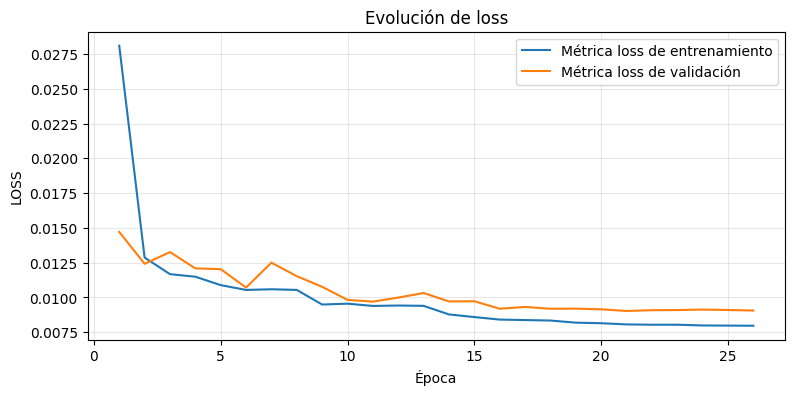

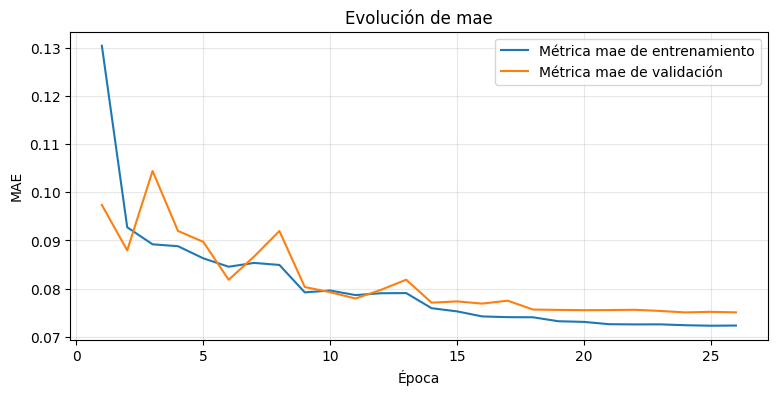

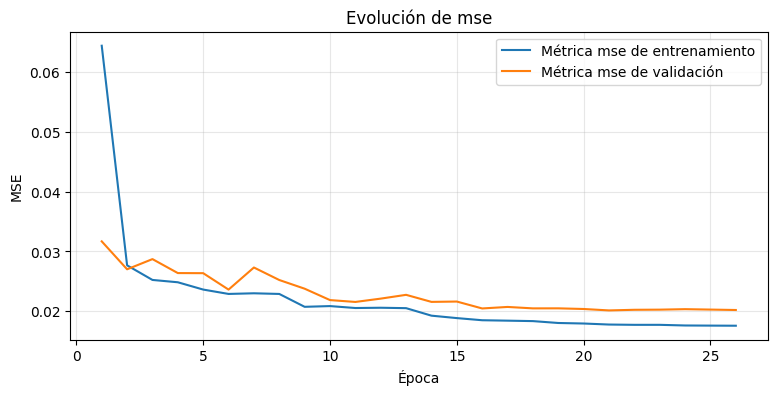

In [8]:
model_data_norm_global = history_norm_global.history
plot_training_metrics(model_data_norm_global)

In [9]:
# Predecimos sobre el conjunto de test
y_pred_norm_global = model.predict(X_test_norm_global)
y_pred_global = y_pred_norm_global * y_std + y_mean

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


Graficamos un par de ejemplos

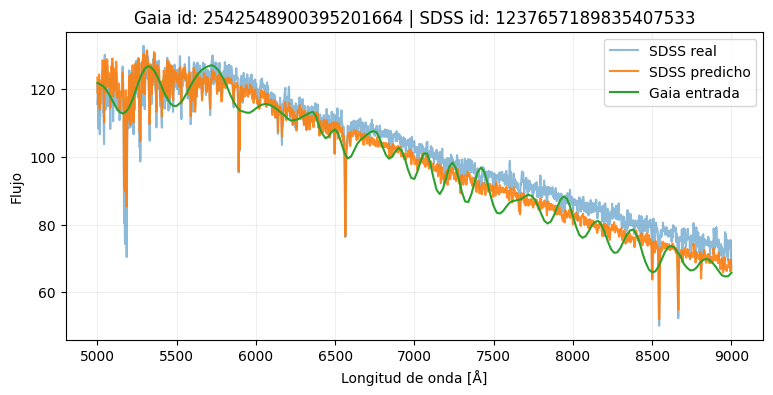

In [10]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_global,
    y_id_test,
    X_test,
    X_id_test
)

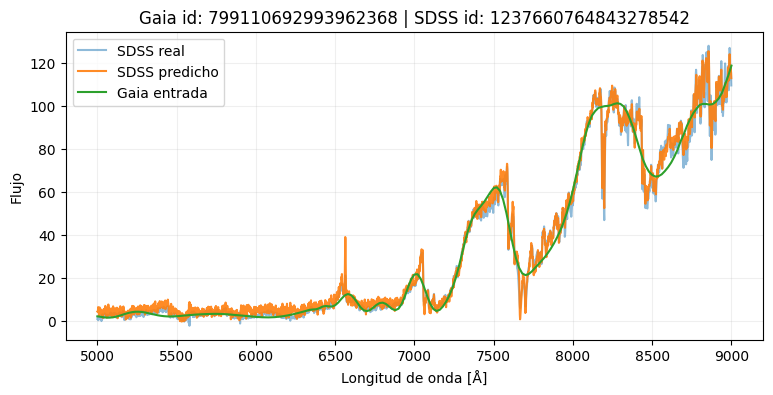

In [11]:
plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_global,
    y_id_test,
    X_test,
    X_id_test
)

In [12]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm_global,
    y_test_norm_global,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0093 - mae: 0.0757 - mse: 0.0208


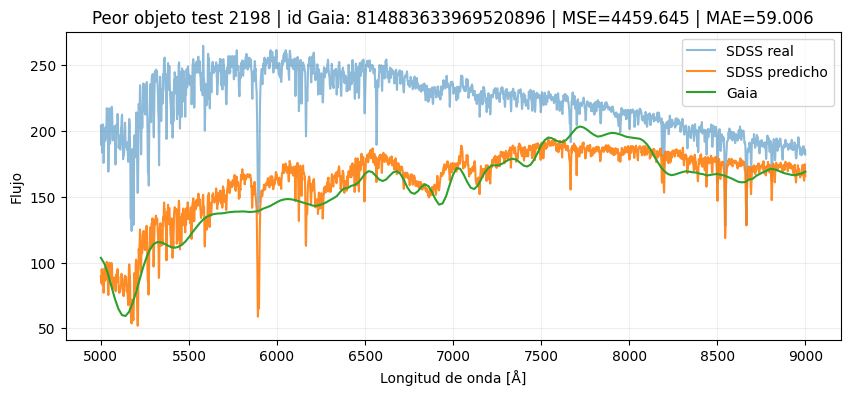

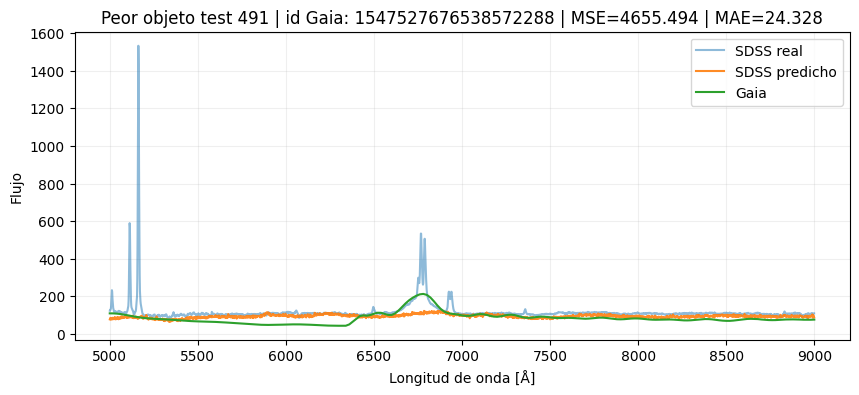

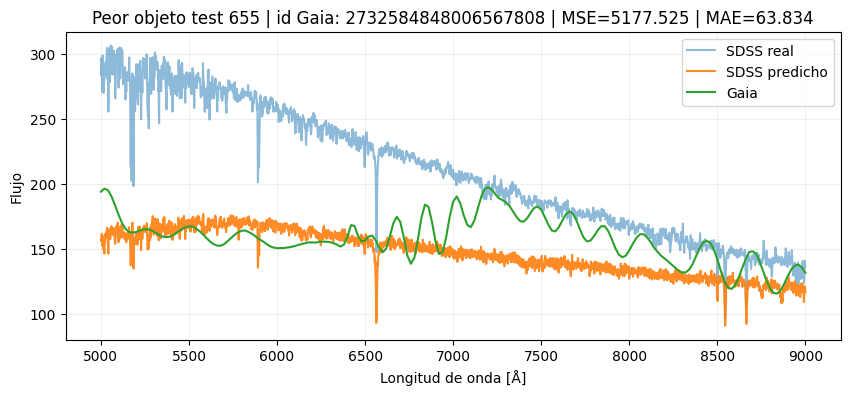

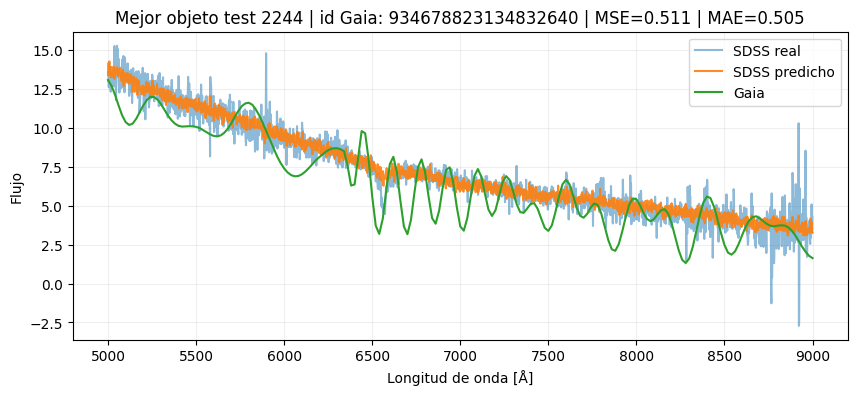

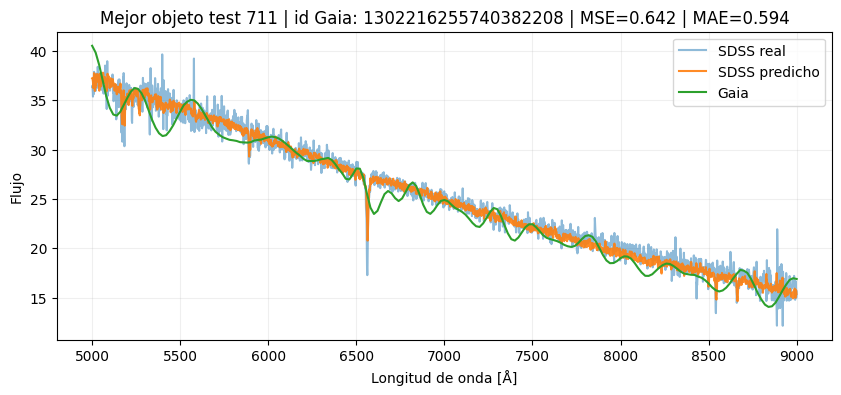

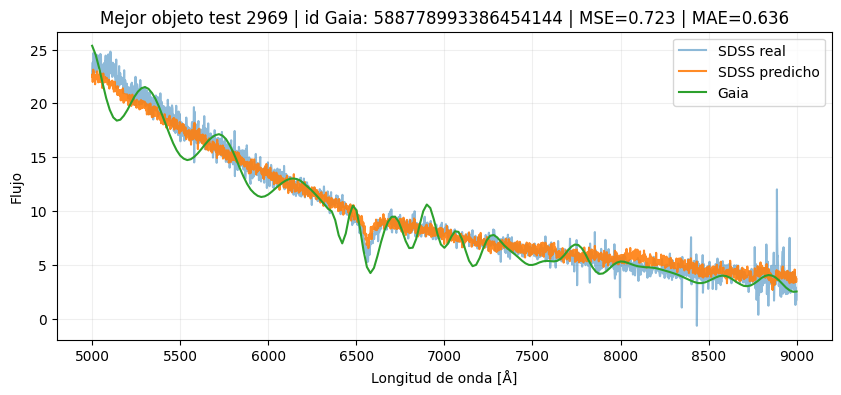

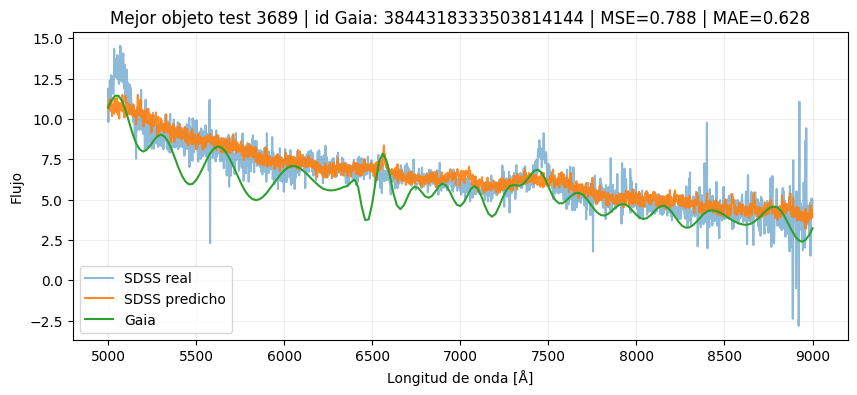

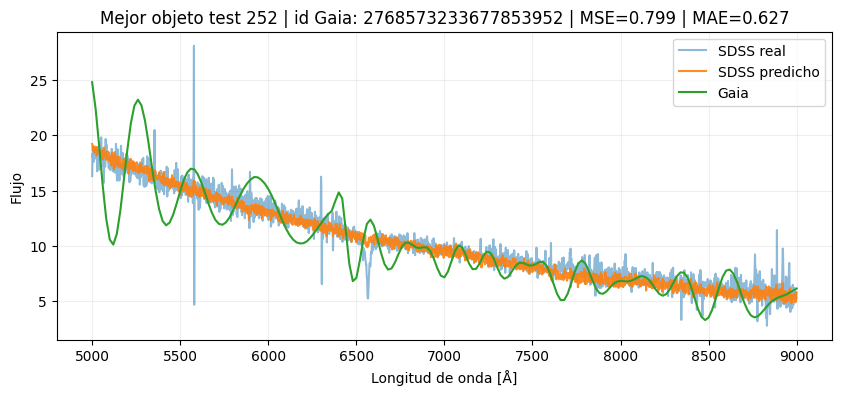

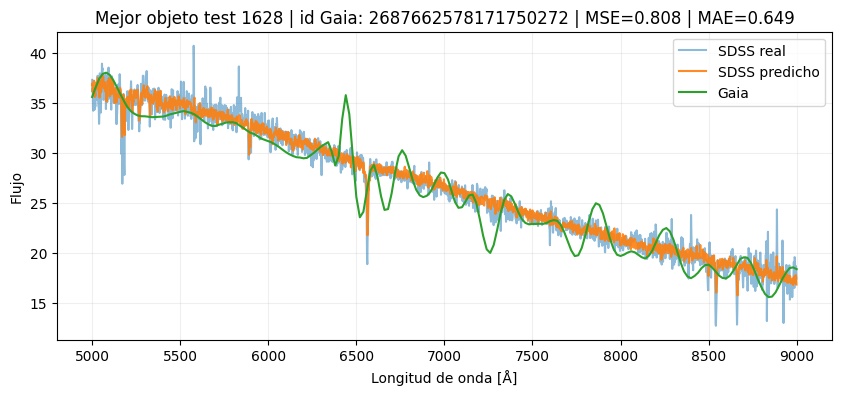

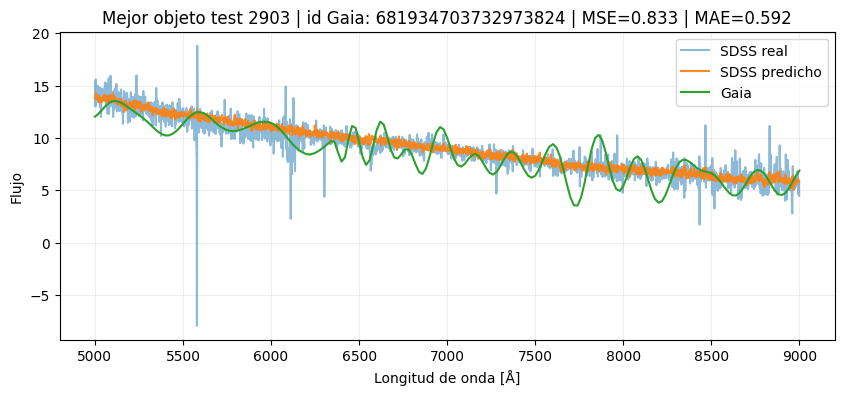

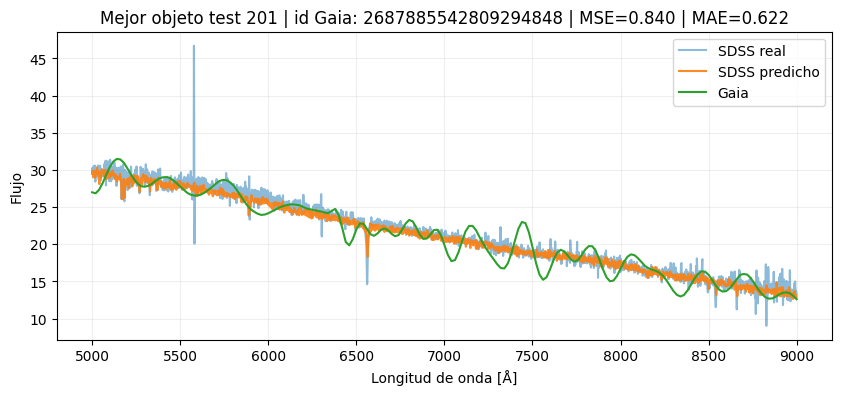

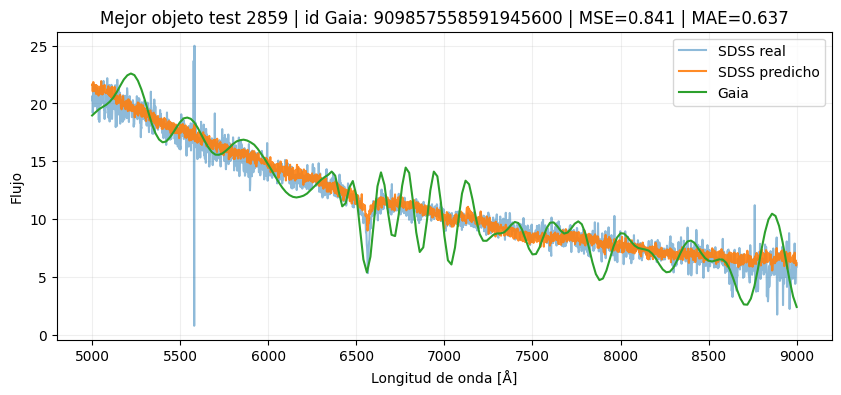

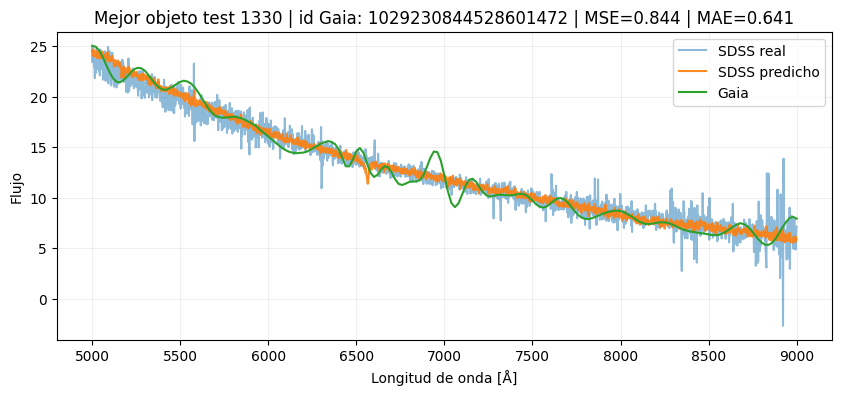

In [13]:
plot_worst_best_predictions(
    y_test,
    y_pred_global,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

Añadimos código para comprobar los valores sacados con iSpec del espectro real y predicho. 

In [14]:
import sys
from pathlib import Path

ISPEC_FUNCTIONS_DIR = Path(
    "../solution/models"
)

if str(ISPEC_FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(ISPEC_FUNCTIONS_DIR))

In [15]:
# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

In [16]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2

In [17]:
# Cargamos Resources
resources = load_ispec_resources()


Recursos de iSpec cargados correctamente.


In [18]:
from astropy.table import Table
# Cargamos la tabla de Gaia guardada en local
gaia_data_path = Path("../data/gaia_data.ecsv")

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

In [19]:
# Analizamos y devolvemos DF con valores ajustados a los espectros
results_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_global,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=150
    )

Espectros analizados:   0%|          | 0/150 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-17 23:21:16,152] [WARNING] [atmospheres:_interpolate:114]: Target point '4642.083931059987 5.5 -0.6693910997863578' is out of bound, using the closest
[2026-08-17 23:21:59,102] [WARNING] [atmospheres:_interpolate:114]: Target point '4941.116963000216 5.420738682721558 -0.43848983890650706' is out of bound, using the closest
[2026-08-17 23:22:15,002] [WARNING] [atmospheres:_interpolate:114]: Target point '5006.222906645974 5.413800000424778 -0.42792597394714504' is out of bound, using the closest


Only LTE


[2026-08-17 23:22:34,443] [WARNING] [atmospheres:_interpolate:114]: Target point '4638.907724638949 5.5 -0.6545832921790125' is out of bound, using the closest


...

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-18 03:06:22,914] [WARNING] [atmospheres:_interpolate:114]: Target point '4255.759050774196 5.5 -0.41302666286726414' is out of bound, using the closest
[2026-08-18 03:06:28,890] [WARNING] [atmospheres:_interpolate:114]: Target point '3967.289744315656 5.5 -0.49138206128531975' is out of bound, using the closest
[2026-08-18 03:06:40,737] [WARNING] [atmospheres:_interpolate:114]: Target point '3974.9511531073103 5.5 -1.4486639970510233' is out of bound, using the closest
[2026-08-18 03:06:58,440] [WARNING] [atmospheres:_interpolate:114]: Target point '3977.3779559130303 5.495228272132232 -1.5210669493091629' is out of bound, using the closest


Only LTE


[2026-08-18 03:08:07,364] [WARNING] [atmospheres:_interpolate:114]: Target point '3906.971488616123 5.5 -0.16365002583781169' is out of bound, using the closest


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


In [20]:
display(results_df)


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5228.920569,4.640982,-0.851193,-128.087776,-0.169542,0.117835
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5816.128005,4.702404,-1.117402,2.903696,-0.004954,0.012434
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6139.737527,4.695610,-1.160715,6141.564748,4.693045,-1.152056,1.827221,-0.002564,0.008659
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6042.269395,4.167486,-0.687873,6039.280247,4.168868,-0.689566,-2.989148,0.001382,-0.001693
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6037.687771,4.298310,-0.610908,6037.126047,4.299782,-0.614335,-0.561725,0.001472,-0.003426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,839,1563780142022633856,6524.167969,4.2145,-0.4674,6598.880164,4.310636,-0.489915,6616.924464,4.301170,-0.493661,18.044301,-0.009466,-0.003747
146,327,1410023851879234688,6045.990234,4.5539,-1.1586,6046.810000,4.555778,-1.158566,6063.085129,4.615934,-1.278423,16.275129,0.060156,-0.119857
147,1687,1314845963554562048,3131.839844,4.9757,0.0187,3878.044981,5.495160,-1.525130,3813.016492,5.467620,-0.873220,-65.028489,-0.027540,0.651910
148,367,1665180059273240192,6108.652344,4.7004,-2.0908,6108.809248,4.704026,-2.337098,6110.213822,4.703476,-2.332047,1.404574,-0.000550,0.005050


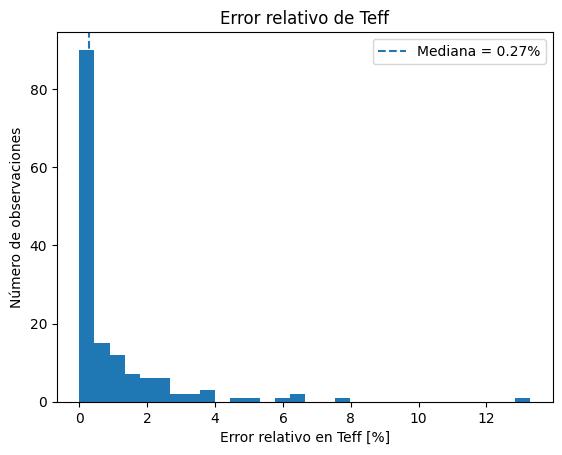

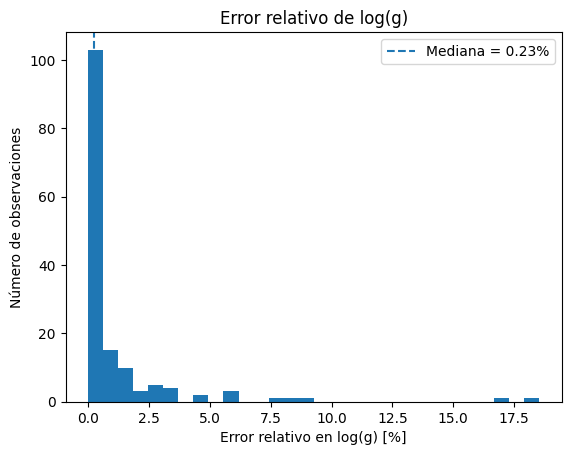

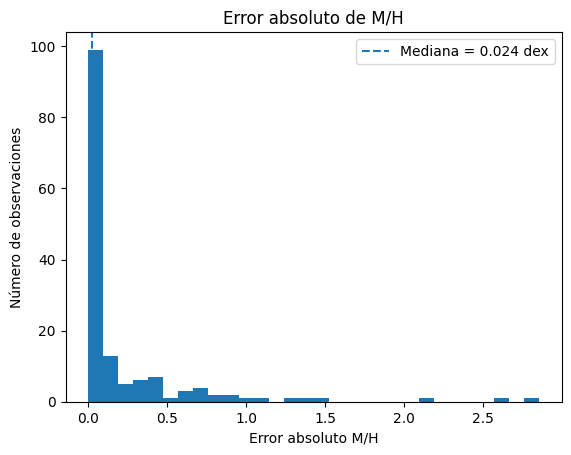

In [21]:
error_df = analyze_ispec_errors(results_df)

In [22]:
display(error_df)

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5228.920569,4.640982,-0.851193,-128.087776,-0.169542,0.117835,128.087776,0.169542,0.117835,2.391032,3.524406
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5816.128005,4.702404,-1.117402,2.903696,-0.004954,0.012434,2.903696,0.004954,0.012434,0.049950,0.105232
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6139.737527,4.695610,-1.160715,6141.564748,4.693045,-1.152056,1.827221,-0.002564,0.008659,1.827221,0.002564,0.008659,0.029761,0.054609
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6042.269395,4.167486,-0.687873,6039.280247,4.168868,-0.689566,-2.989148,0.001382,-0.001693,2.989148,0.001382,0.001693,0.049471,0.033159
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6037.687771,4.298310,-0.610908,6037.126047,4.299782,-0.614335,-0.561725,0.001472,-0.003426,0.561725,0.001472,0.003426,0.009304,0.034245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,839,1563780142022633856,6524.167969,4.2145,-0.4674,6598.880164,4.310636,-0.489915,6616.924464,4.301170,-0.493661,18.044301,-0.009466,-0.003747,18.044301,0.009466,0.003747,0.273445,0.219589
146,327,1410023851879234688,6045.990234,4.5539,-1.1586,6046.810000,4.555778,-1.158566,6063.085129,4.615934,-1.278423,16.275129,0.060156,-0.119857,16.275129,0.060156,0.119857,0.269152,1.320427
147,1687,1314845963554562048,3131.839844,4.9757,0.0187,3878.044981,5.495160,-1.525130,3813.016492,5.467620,-0.873220,-65.028489,-0.027540,0.651910,65.028489,0.027540,0.651910,1.676837,0.501170
148,367,1665180059273240192,6108.652344,4.7004,-2.0908,6108.809248,4.704026,-2.337098,6110.213822,4.703476,-2.332047,1.404574,-0.000550,0.005050,1.404574,0.000550,0.005050,0.022993,0.011684


Intentamos el mismo modelo pero con normalización espectro a espectro con la mediana.

In [23]:
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

y_scale_train = np.nanmedian(np.abs(y_train), axis=1, keepdims=True)
y_scale_val = np.nanmedian(np.abs(y_val), axis=1, keepdims=True)
y_scale_test = np.nanmedian(np.abs(y_test), axis=1, keepdims=True)

X_train_norm_median_spec = X_train / X_scale_train
X_val_norm_median_spec = X_val / X_scale_val
X_test_norm_median_spec = X_test / X_scale_test

y_train_norm_median_spec = y_train / y_scale_train
y_val_norm_median_spec = y_val / y_scale_val
y_test_norm_median_spec = y_test / y_scale_test

In [24]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model_median_spec = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_median_spec.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_median_spec.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Entrenamos el modelo
history = model_median_spec.fit(
    X_train_norm_median_spec,
    y_train_norm_median_spec,
    validation_data=(X_val_norm_median_spec, y_val_norm_median_spec),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0646 - mae: 0.1927 - mse: 0.1459 - val_loss: 0.0051 - val_mae: 0.0588 - val_mse: 0.0152 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0047 - mae: 0.0538 - mse: 0.0115 - val_loss: 0.0047 - val_mae: 0.0566 - val_mse: 0.0143 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0043 - mae: 0.0508 - mse: 0.0111 - val_loss: 0.0043 - val_mae: 0.0505 - val_mse: 0.0133 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0041 - mae: 0.0498 - mse: 0.0109 - val_loss: 0.0041 - val_mae: 0.0495 - val_mse: 0.0128 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0040 - mae: 0.0485 - mse: 0.0104 - val_loss: 0.0040 - val_mae: 0.0498 - val_mse: 0.0127 - learning_rate: 1.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0039 - mae: 0.0480 - mse: 0.0106 - v

In [26]:
y_pred_norm_median_spec = model_median_spec.predict(X_test_norm_median_spec)
y_pred_median_spec = y_pred_norm_median_spec * y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [27]:
test_loss_median_spec, test_mae_median_spec, test_mse_median_spec = model_median_spec.evaluate(
    X_test_norm_median_spec,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0428 - mse: 0.0091


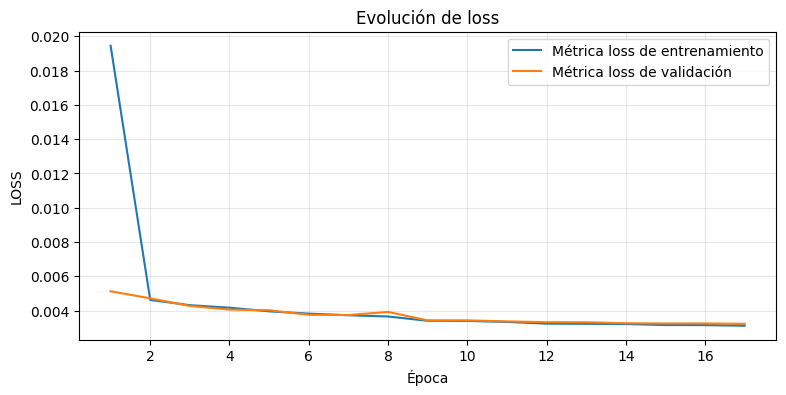

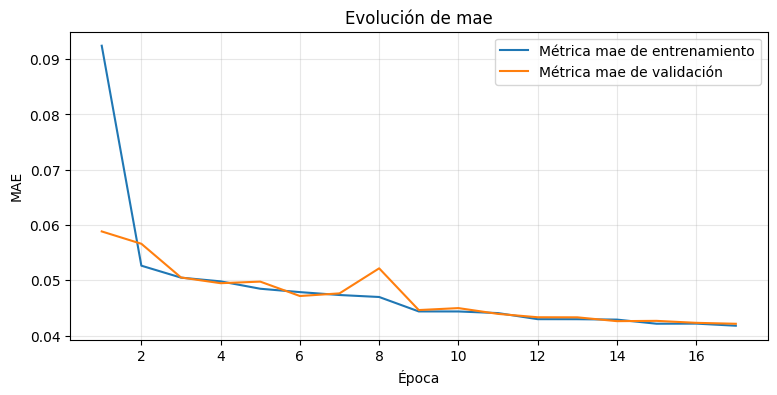

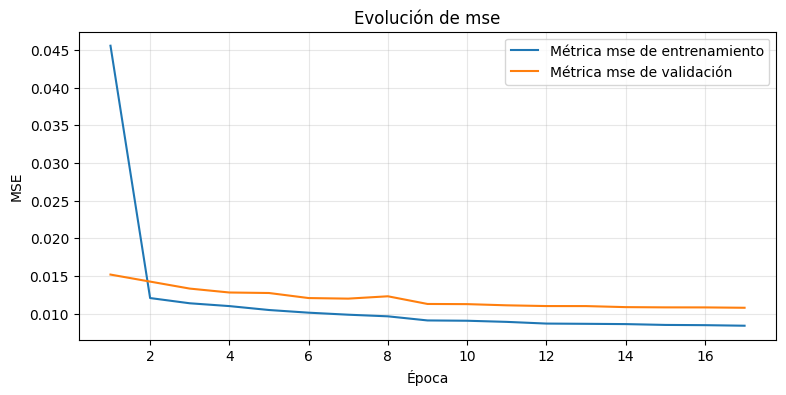

In [28]:
model_data_median_spec = history.history
plot_training_metrics(model_data_median_spec)

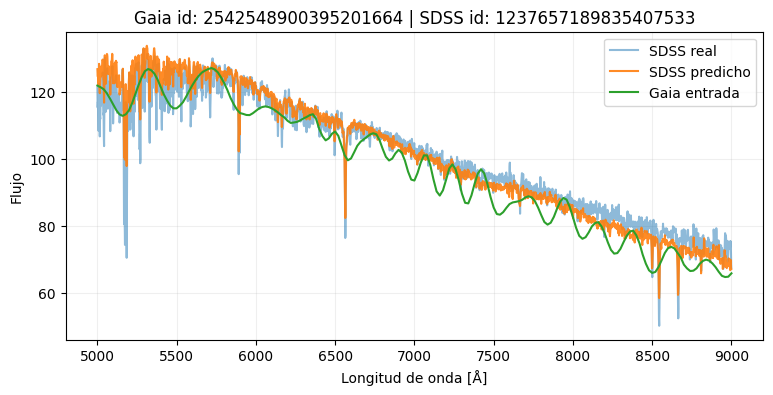

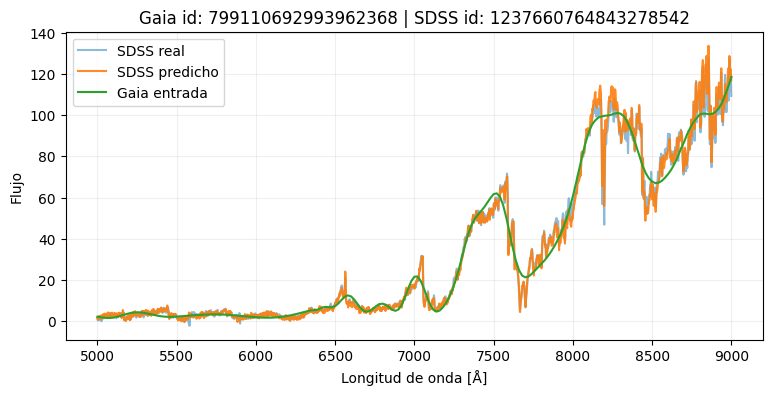

In [29]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_median_spec,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_median_spec,
    y_id_test,
    X_test,
    X_id_test
)

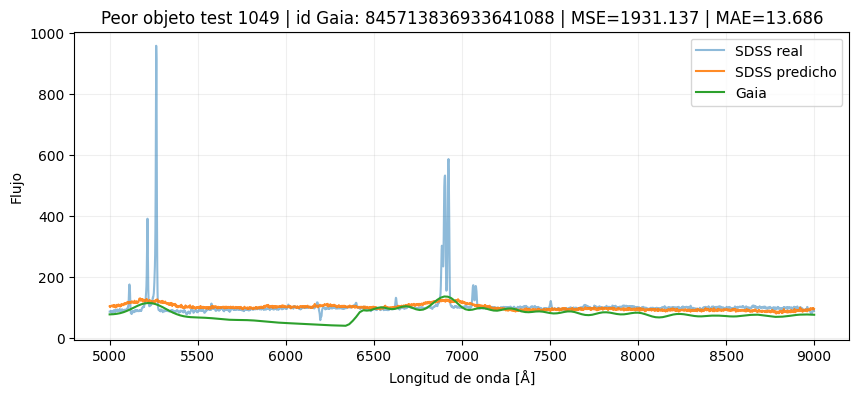

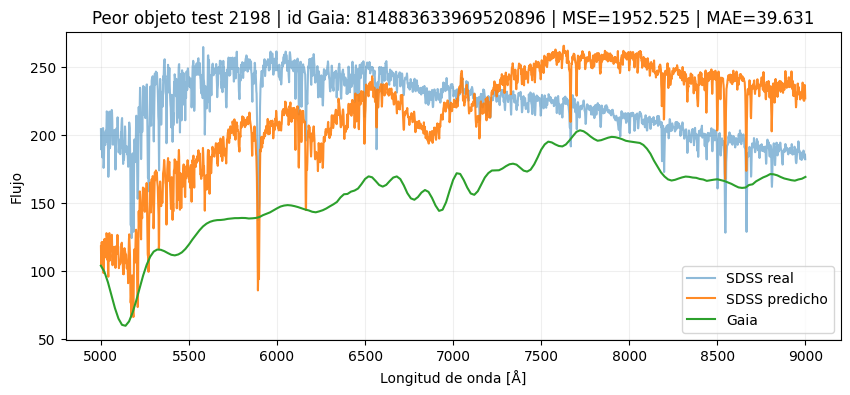

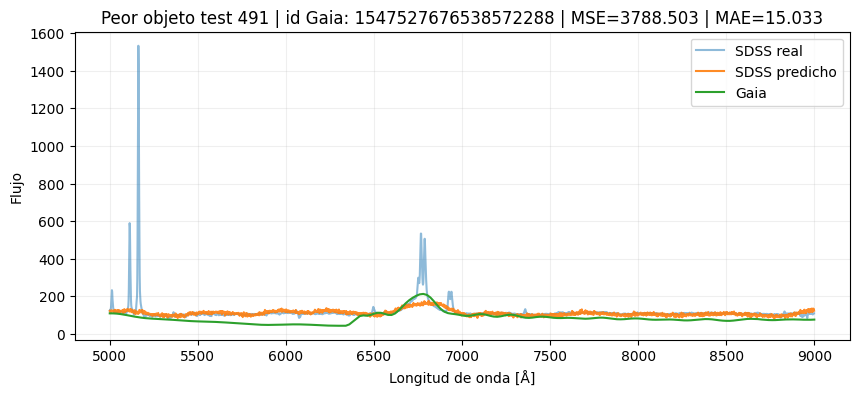

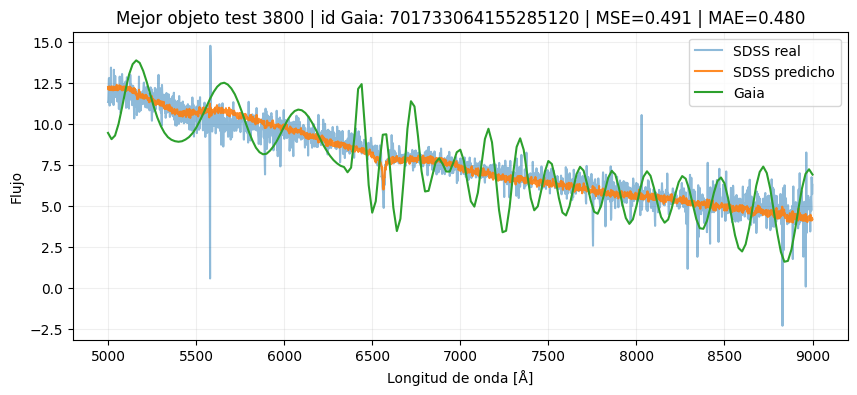

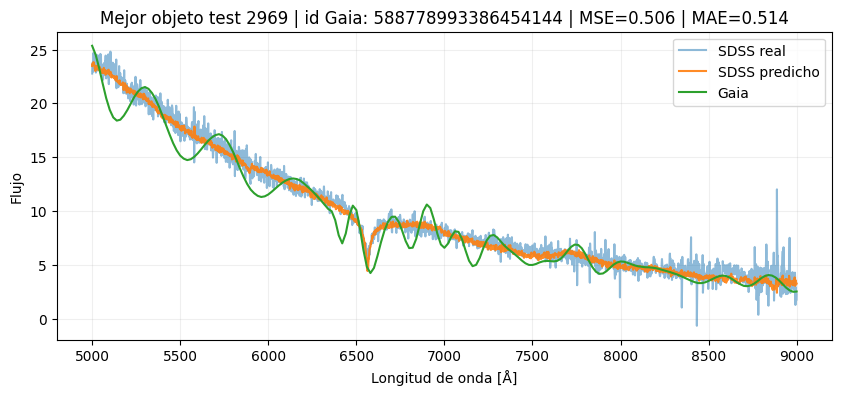

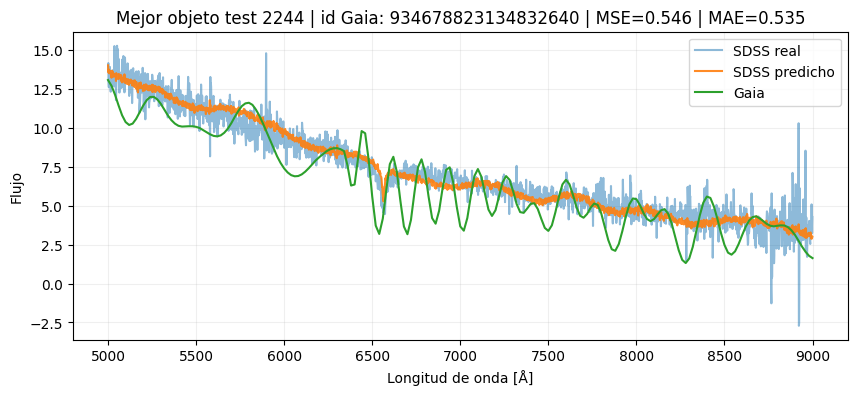

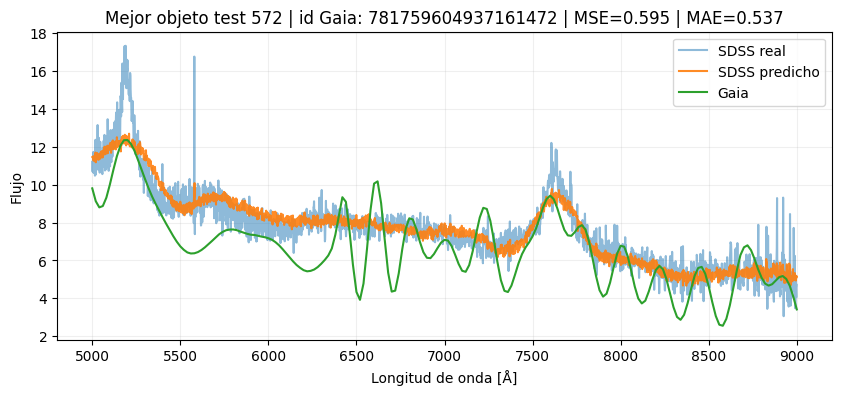

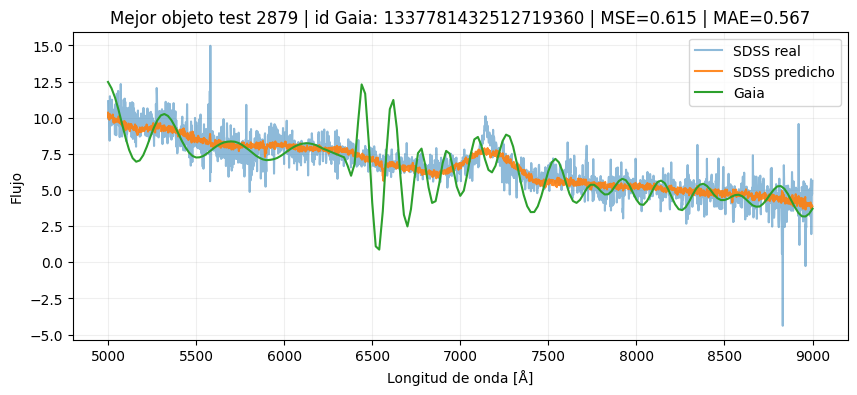

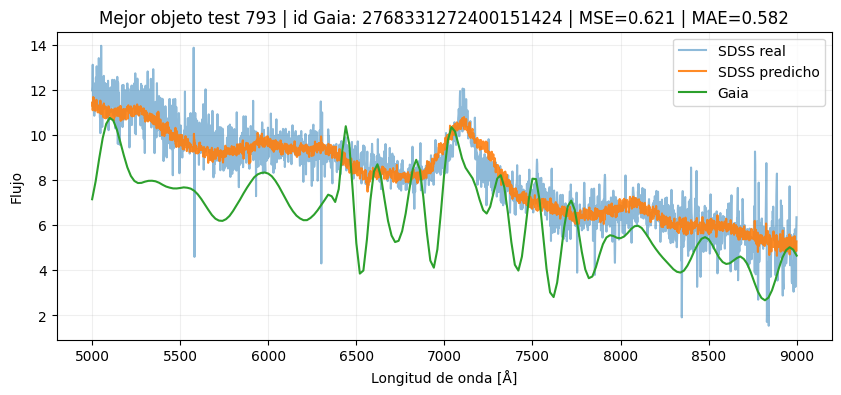

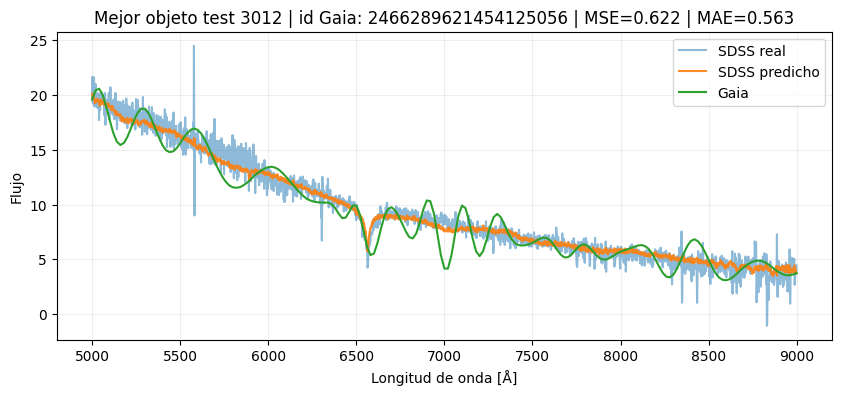

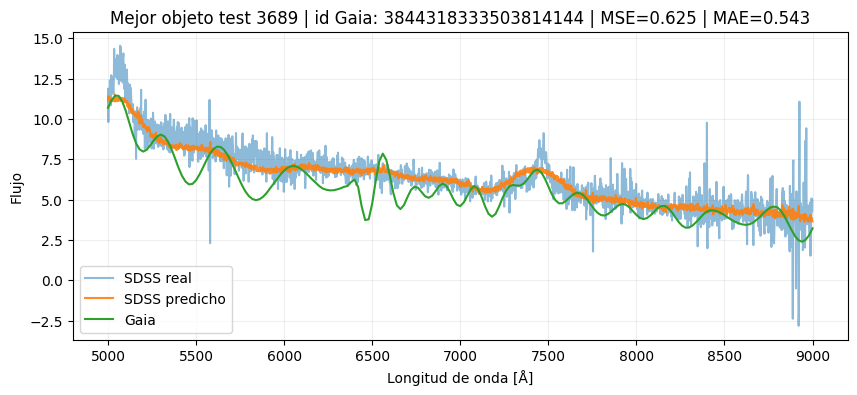

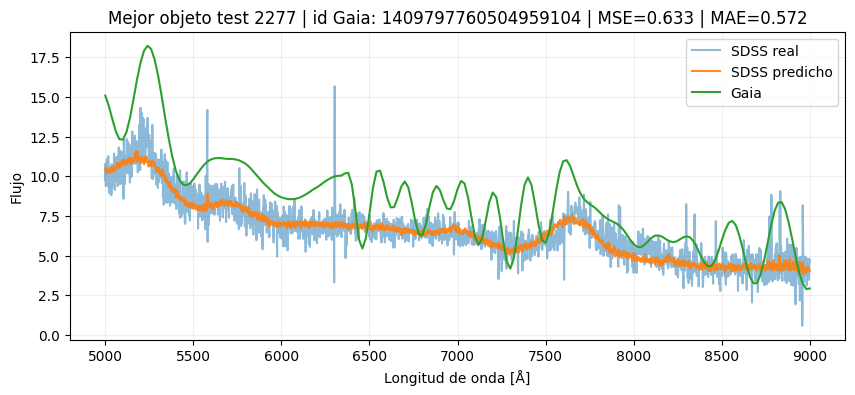

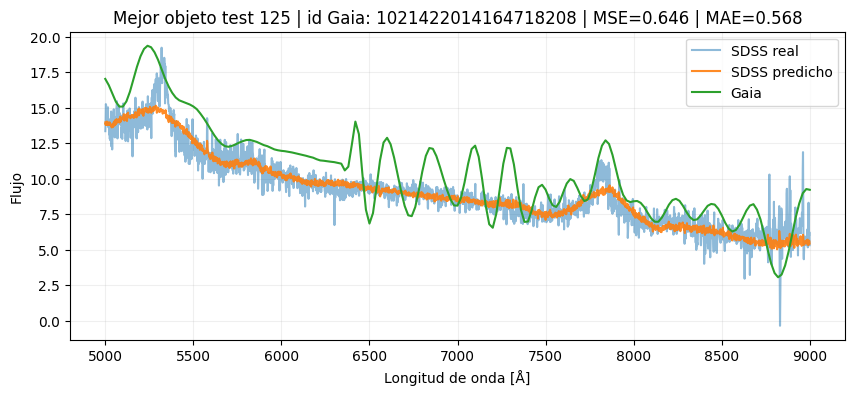

In [30]:
plot_worst_best_predictions(
    y_test,
    y_pred_median_spec,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

Igual que en el anterior caso, analizamos con iSpec

In [31]:
results_2_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_median_spec,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=150
)
display(results_2_df)

Espectros analizados:   0%|          | 0/150 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-18 03:22:58,561] [WARNING] [atmospheres:_interpolate:114]: Target point '4642.083931059987 5.5 -0.6693910997863578' is out of bound, using the closest
[2026-08-18 03:23:38,135] [WARNING] [atmospheres:_interpolate:114]: Target point '4941.116963000216 5.420738682721558 -0.43848983890650706' is out of bound, using the closest
[2026-08-18 03:23:53,874] [WARNING] [atmospheres:_interpolate:114]: Target point '5006.222906645974 5.413800000424778 -0.42792597394714504' is out of bound, using the closest


Only LTE


[2026-08-18 03:24:12,846] [WARNING] [atmospheres:_interpolate:114]: Target point '4651.630510987879 5.5 -0.6701104145118257' is out of bound, using the closest
[2026-08-18 03:24:59,141] [WARNING] [atmospheres:_interpolate:114]: Target point '4728.390792378151 5.462175841364987 -1.1073689038438814' is out of bound, using the closest
[2026-08-18 03:25:05,515] [WARNING] [atmospheres:_interpolate:114]: Target point '5287.182538100579 5.364326470734985 -0.845103080518503' is out of bound, using the closest


...

[2026-08-18 07:09:20,042] [WARNING] [atmospheres:_interpolate:114]: Target point '4255.759050774196 5.5 -0.41302666286726414' is out of bound, using the closest
[2026-08-18 07:09:26,206] [WARNING] [atmospheres:_interpolate:114]: Target point '3967.289744315656 5.5 -0.49138206128531975' is out of bound, using the closest
[2026-08-18 07:09:38,094] [WARNING] [atmospheres:_interpolate:114]: Target point '3974.9511531073103 5.5 -1.4486639970510233' is out of bound, using the closest
[2026-08-18 07:09:55,848] [WARNING] [atmospheres:_interpolate:114]: Target point '3977.3779559130303 5.495228272132232 -1.5210669493091629' is out of bound, using the closest


Only LTE


[2026-08-18 07:10:34,825] [WARNING] [atmospheres:_interpolate:114]: Target point '3964.534559579822 5.5 -0.7139636666969092' is out of bound, using the closest
[2026-08-18 07:11:01,769] [WARNING] [atmospheres:_interpolate:114]: Target point '4125.215148751916 5.499469125916744 -0.3912496780791431' is out of bound, using the closest


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5200.306898,4.670266,-0.845214,-156.701447,-0.140259,0.123814
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5826.800681,4.710970,-1.131019,13.576373,0.003613,-0.001182
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6139.737527,4.695610,-1.160715,6143.740594,4.693005,-1.151787,4.003068,-0.002605,0.008928
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6042.269395,4.167486,-0.687873,6038.644026,4.169336,-0.689354,-3.625369,0.001850,-0.001481
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6037.687771,4.298310,-0.610908,6032.329924,4.292645,-0.607621,-5.357848,-0.005666,0.003287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,839,1563780142022633856,6524.167969,4.2145,-0.4674,6598.880164,4.310636,-0.489915,6549.099031,4.269100,-0.476423,-49.781133,-0.041536,0.013491
146,327,1410023851879234688,6045.990234,4.5539,-1.1586,6046.810000,4.555778,-1.158566,6079.624451,4.597161,-1.198207,32.814451,0.041383,-0.039641
147,1687,1314845963554562048,3131.839844,4.9757,0.0187,3878.044981,5.495160,-1.525130,3895.058604,5.486675,-0.474253,17.013623,-0.008485,1.050877
148,367,1665180059273240192,6108.652344,4.7004,-2.0908,6108.809248,4.704026,-2.337098,6109.255061,4.708357,-2.738558,0.445812,0.004331,-0.401460


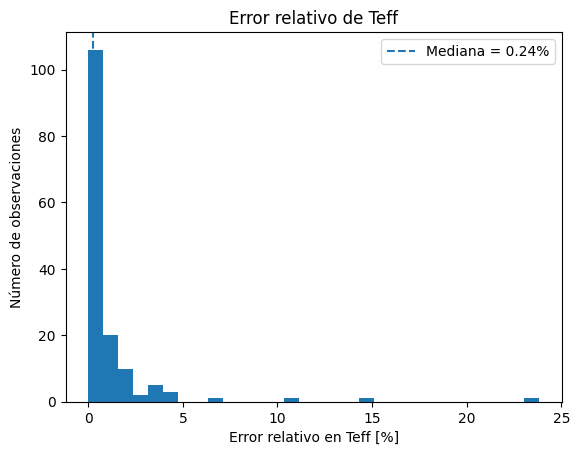

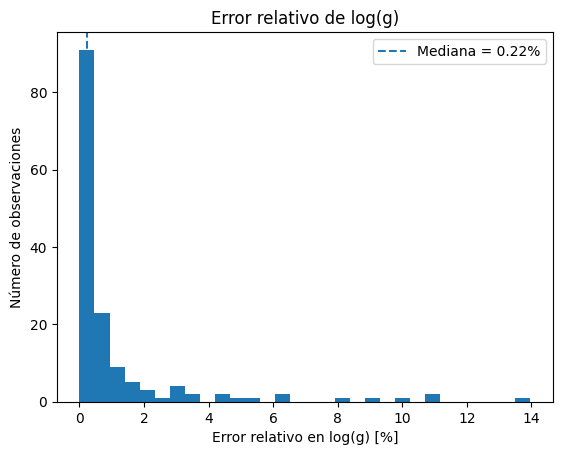

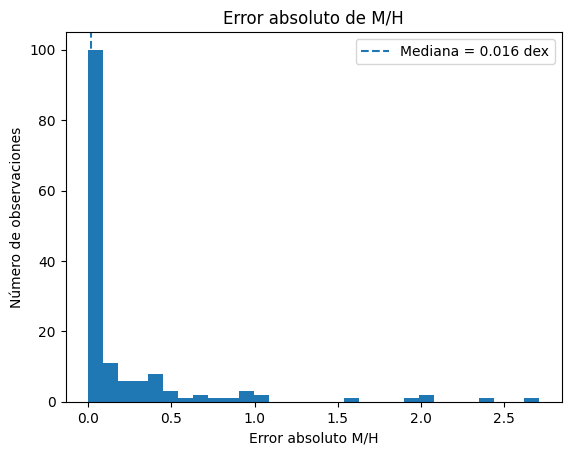

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5200.306898,4.670266,-0.845214,-156.701447,-0.140259,0.123814,156.701447,0.140259,0.123814,2.925167,2.915667
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5826.800681,4.710970,-1.131019,13.576373,0.003613,-0.001182,13.576373,0.003613,0.001182,0.233543,0.076748
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6139.737527,4.695610,-1.160715,6143.740594,4.693005,-1.151787,4.003068,-0.002605,0.008928,4.003068,0.002605,0.008928,0.065199,0.055474
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6042.269395,4.167486,-0.687873,6038.644026,4.169336,-0.689354,-3.625369,0.001850,-0.001481,3.625369,0.001850,0.001481,0.060000,0.044384
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6037.687771,4.298310,-0.610908,6032.329924,4.292645,-0.607621,-5.357848,-0.005666,0.003287,5.357848,0.005666,0.003287,0.088740,0.131809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,839,1563780142022633856,6524.167969,4.2145,-0.4674,6598.880164,4.310636,-0.489915,6549.099031,4.269100,-0.476423,-49.781133,-0.041536,0.013491,49.781133,0.041536,0.013491,0.754388,0.963570
146,327,1410023851879234688,6045.990234,4.5539,-1.1586,6046.810000,4.555778,-1.158566,6079.624451,4.597161,-1.198207,32.814451,0.041383,-0.039641,32.814451,0.041383,0.039641,0.542674,0.908354
147,1687,1314845963554562048,3131.839844,4.9757,0.0187,3878.044981,5.495160,-1.525130,3895.058604,5.486675,-0.474253,17.013623,-0.008485,1.050877,17.013623,0.008485,1.050877,0.438716,0.154405
148,367,1665180059273240192,6108.652344,4.7004,-2.0908,6108.809248,4.704026,-2.337098,6109.255061,4.708357,-2.738558,0.445812,0.004331,-0.401460,0.445812,0.004331,0.401460,0.007298,0.092071


In [32]:
error_2_df = analyze_ispec_errors(results_2_df)
display(error_2_df)

Misma estructura pero con normalización con el máximo por espectro.

In [33]:
# Máximo absoluto por espectro
X_max_train = np.nanmax(np.abs(X_train), axis=1, keepdims=True)
X_max_val = np.nanmax(np.abs(X_val), axis=1, keepdims=True)
X_max_test = np.nanmax(np.abs(X_test), axis=1, keepdims=True)

y_max_train = np.nanmax(np.abs(y_train), axis=1, keepdims=True)
y_max_val = np.nanmax(np.abs(y_val), axis=1, keepdims=True)
y_max_test = np.nanmax(np.abs(y_test), axis=1, keepdims=True)

# Normalización
X_train_norm_max = X_train / X_max_train
X_val_norm_max = X_val / X_max_val
X_test_norm_max = X_test / X_max_test

y_train_norm_max = y_train / y_max_train
y_val_norm_max = y_val / y_max_val
y_test_norm_max = y_test / y_max_test

In [34]:
model_per_spectrum_max = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_per_spectrum_max.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_per_spectrum_max.summary()

history_max_spectrum = model_per_spectrum_max.fit(
    X_train_norm_max,
    y_train_norm_max,
    validation_data=(X_val_norm_max, y_val_norm_max),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 0.0261 - mae: 0.1438 - mse: 0.0523 - val_loss: 0.0054 - val_mae: 0.0727 - val_mse: 0.0107 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 0.0051 - mae: 0.0694 - mse: 0.0103 - val_loss: 0.0052 - val_mae: 0.0707 - val_mse: 0.0103 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0051 - mae: 0.0694 - mse: 0.0101 - val_loss: 0.0068 - val_mae: 0.0932 - val_mse: 0.0136 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0050 - mae: 0.0682 - mse: 0.0099 - val_loss: 0.0050 - val_mae: 0.0714 - val_mse: 0.0100 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0048 - mae: 0.0663 - mse: 0.0095 - val_loss: 0.0049 - val_mae: 0.0655 - val_mse: 0.0098 - learning_rate: 1.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0047 - mae: 0.0659 - mse: 0.0093 - v

In [35]:
y_pred_norm_max = model_per_spectrum_max.predict(X_test_norm_max)
y_pred_per_spectrum_max = y_pred_norm_max * y_max_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [36]:
test_loss_per_spectrum_max, test_mae_per_spectrum_max, test_mse_per_spectrum_max = model_per_spectrum_max.evaluate(
    X_test_norm_max,
    y_test_norm_max,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0048 - mae: 0.0655 - mse: 0.0097


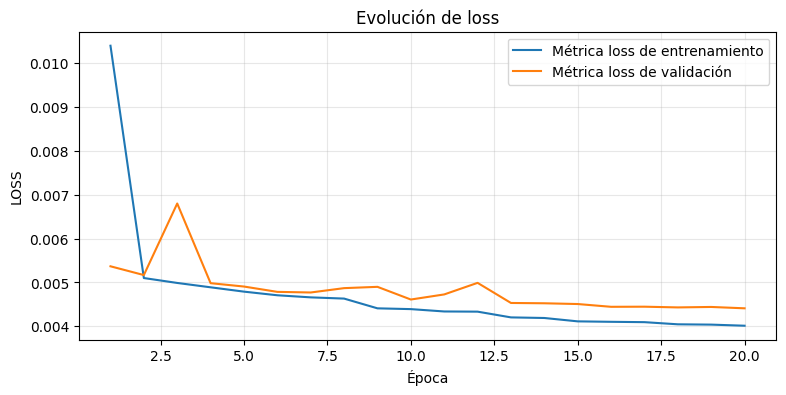

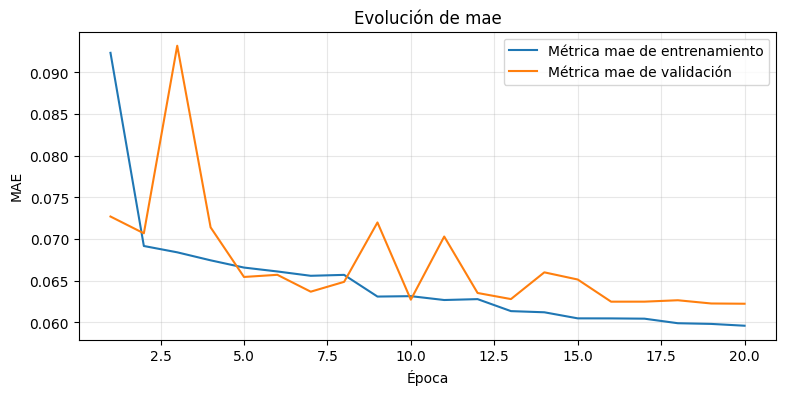

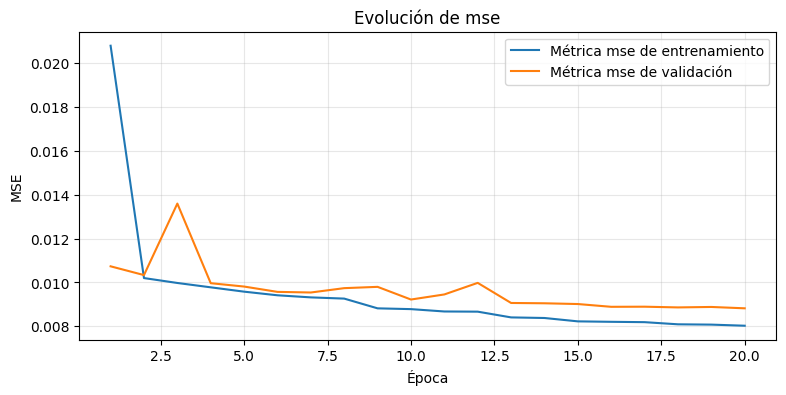

In [37]:
model_data_max = history_max_spectrum.history
plot_training_metrics(model_data_max)


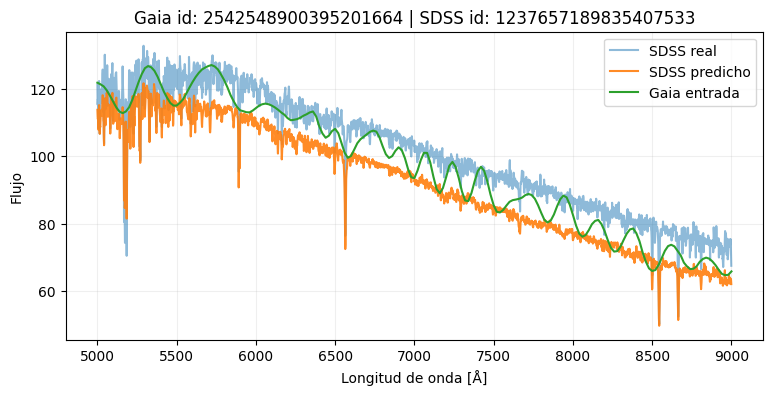

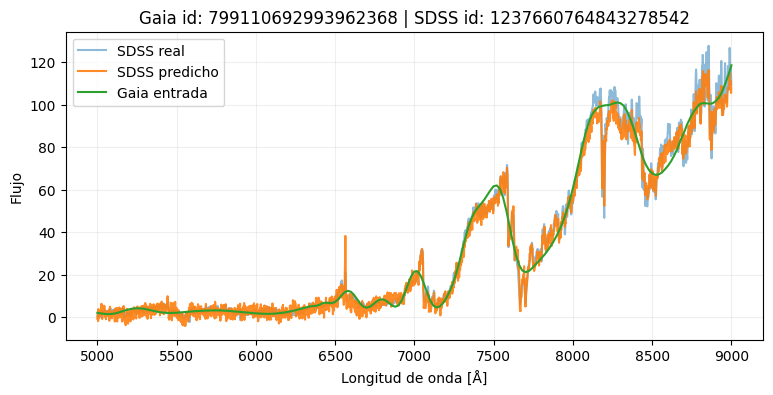

In [38]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_per_spectrum_max,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_per_spectrum_max,
    y_id_test,
    X_test,
    X_id_test
)

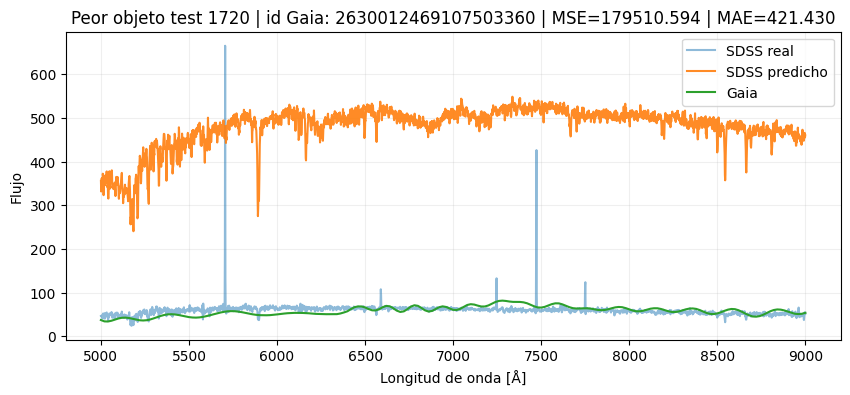

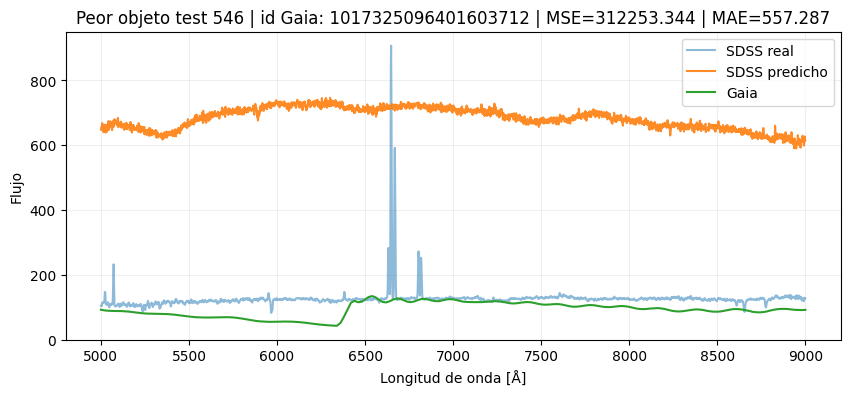

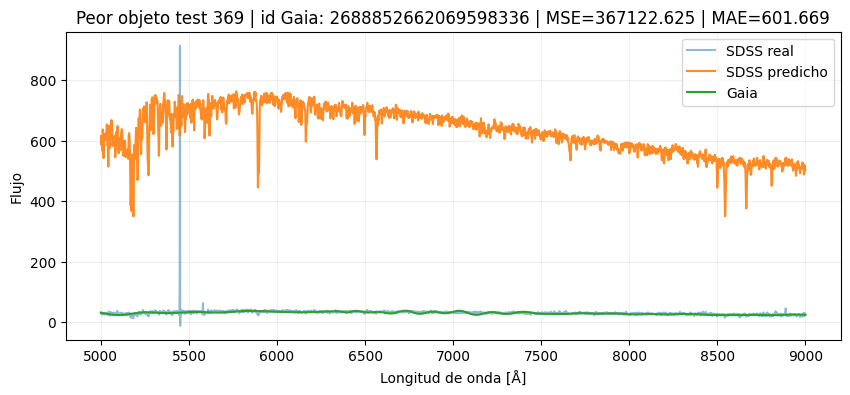

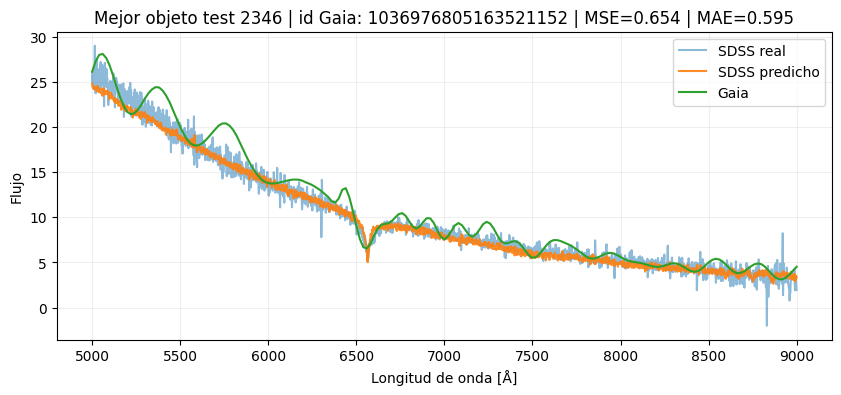

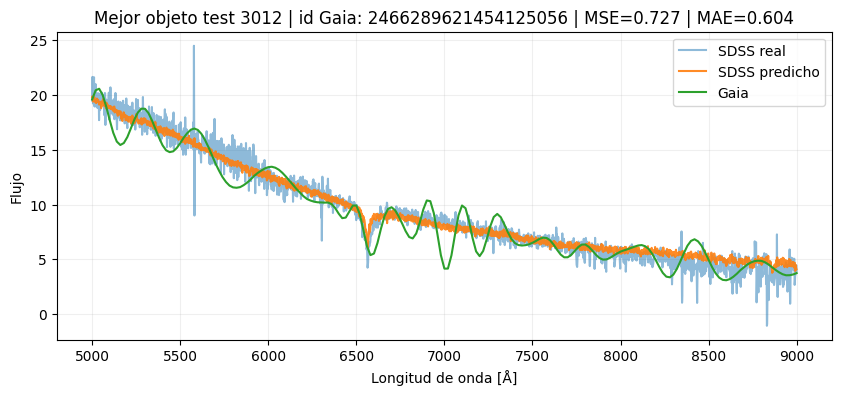

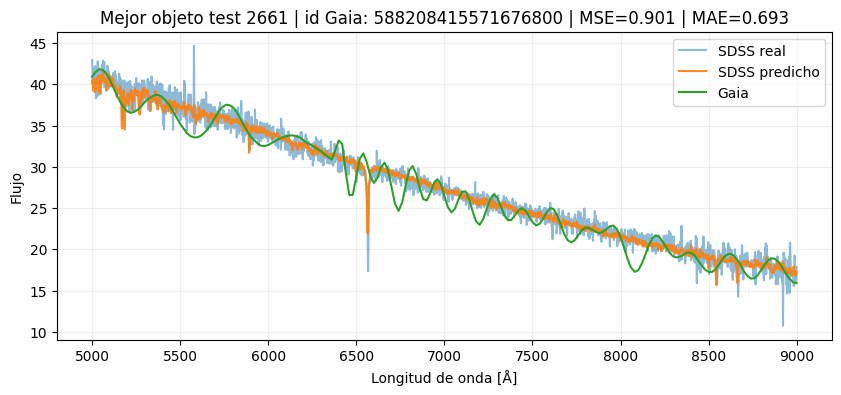

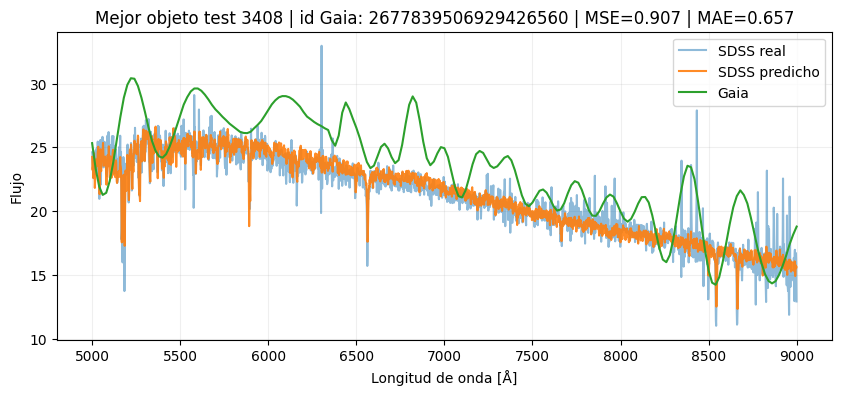

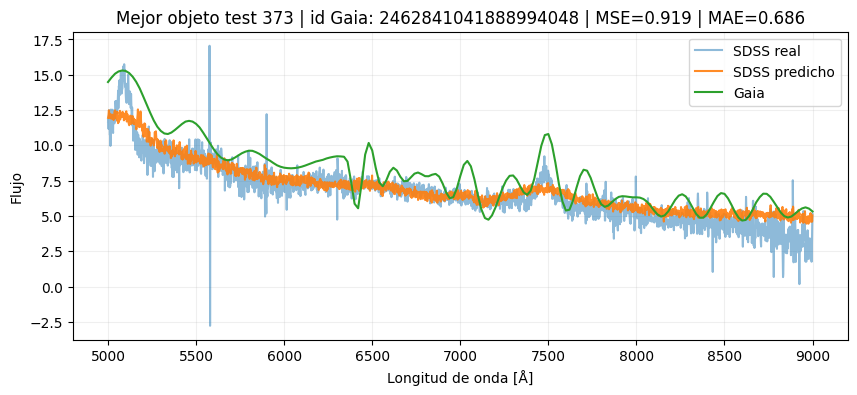

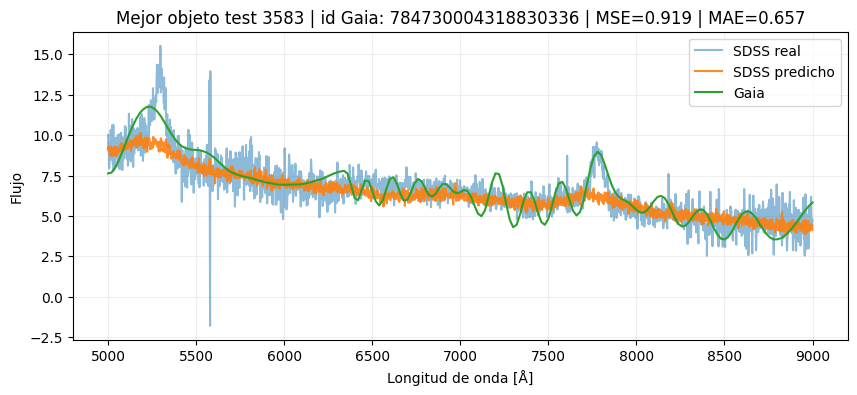

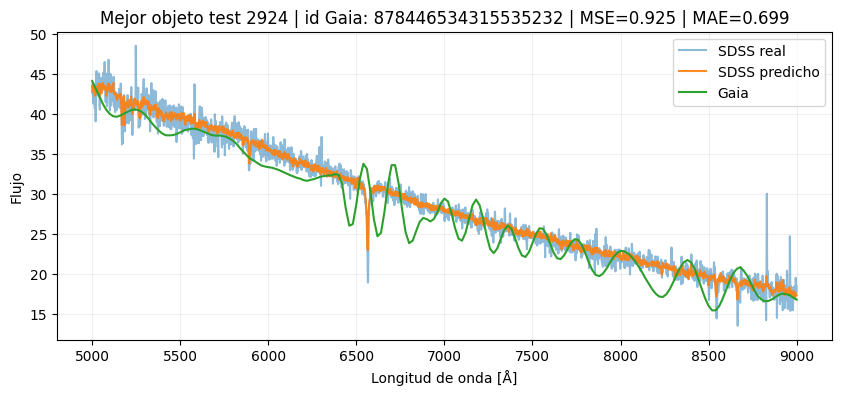

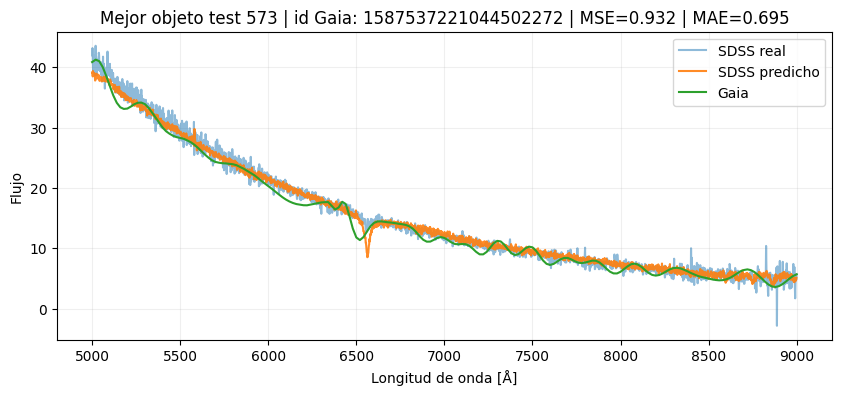

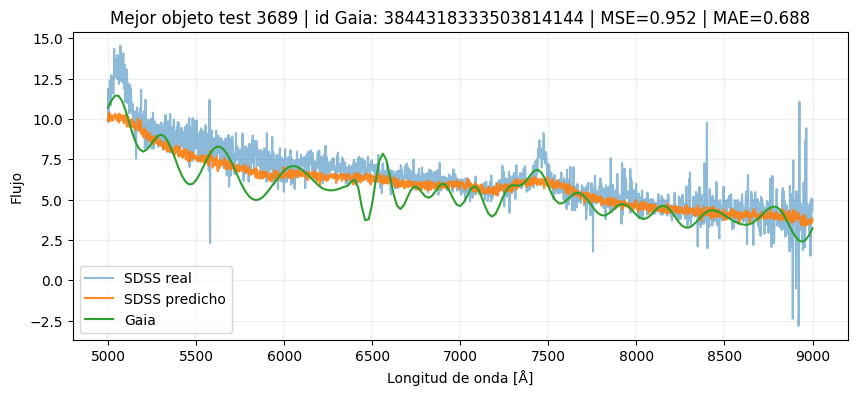

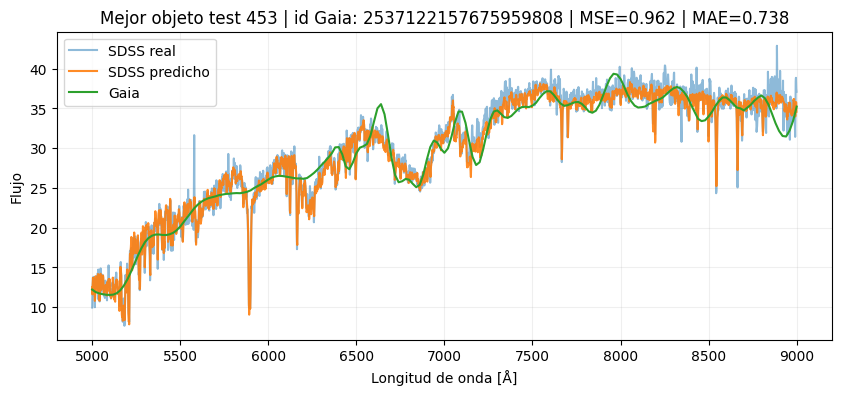

In [39]:
plot_worst_best_predictions(
    y_test,
    y_pred_per_spectrum_max,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

In [40]:
results_3_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_per_spectrum_max,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=150
)
display(results_3_df)

Espectros analizados:   0%|          | 0/150 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-18 07:26:09,645] [WARNING] [atmospheres:_interpolate:114]: Target point '4642.083931059987 5.5 -0.6693910997863578' is out of bound, using the closest
[2026-08-18 07:26:49,197] [WARNING] [atmospheres:_interpolate:114]: Target point '4941.116963000216 5.420738682721558 -0.43848983890650706' is out of bound, using the closest
[2026-08-18 07:27:04,512] [WARNING] [atmospheres:_interpolate:114]: Target point '5006.222906645974 5.413800000424778 -0.42792597394714504' is out of bound, using the closest


Only LTE


[2026-08-18 07:27:23,155] [WARNING] [atmospheres:_interpolate:114]: Target point '4646.033145334304 5.5 -0.6521554307211848' is out of bound, using the closest
[2026-08-18 07:28:02,752] [WARNING] [atmospheres:_interpolate:114]: Target point '4790.693251225544 5.5 -0.9189023706925135' is out of bound, using the closest


...

[2026-08-18 11:13:29,197] [WARNING] [atmospheres:_interpolate:114]: Target point '4255.759050774196 5.5 -0.41302666286726414' is out of bound, using the closest
[2026-08-18 11:13:35,188] [WARNING] [atmospheres:_interpolate:114]: Target point '3967.289744315656 5.5 -0.49138206128531975' is out of bound, using the closest
[2026-08-18 11:13:47,024] [WARNING] [atmospheres:_interpolate:114]: Target point '3974.9511531073103 5.5 -1.4486639970510233' is out of bound, using the closest
[2026-08-18 11:14:04,665] [WARNING] [atmospheres:_interpolate:114]: Target point '3977.3779559130303 5.495228272132232 -1.5210669493091629' is out of bound, using the closest


Only LTE


[2026-08-18 11:14:46,591] [WARNING] [atmospheres:_interpolate:114]: Target point '3901.6672838232193 5.5 -0.0765703980363911' is out of bound, using the closest


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5214.268590,4.659193,-0.839730,-142.739755,-0.151332,0.129299
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5823.788007,4.710005,-1.125039,10.563699,0.002648,0.004798
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6139.737527,4.695610,-1.160715,6143.157177,4.692623,-1.156016,3.419651,-0.002987,0.004699
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6042.269395,4.167486,-0.687873,6033.668945,4.165500,-0.689000,-8.600449,-0.001986,-0.001127
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6037.687771,4.298310,-0.610908,6032.771879,4.297565,-0.608763,-4.915893,-0.000745,0.002146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,839,1563780142022633856,6524.167969,4.2145,-0.4674,6598.880164,4.310636,-0.489915,6547.616551,4.269460,-0.475265,-51.263613,-0.041176,0.014649
146,327,1410023851879234688,6045.990234,4.5539,-1.1586,6046.810000,4.555778,-1.158566,6080.666555,4.598771,-1.200786,33.856555,0.042992,-0.042220
147,1687,1314845963554562048,3131.839844,4.9757,0.0187,3878.044981,5.495160,-1.525130,3835.407856,5.071712,-0.914345,-42.637125,-0.423448,0.610785
148,367,1665180059273240192,6108.652344,4.7004,-2.0908,6108.809248,4.704026,-2.337098,6109.970319,4.704225,-2.334926,1.161070,0.000199,0.002171


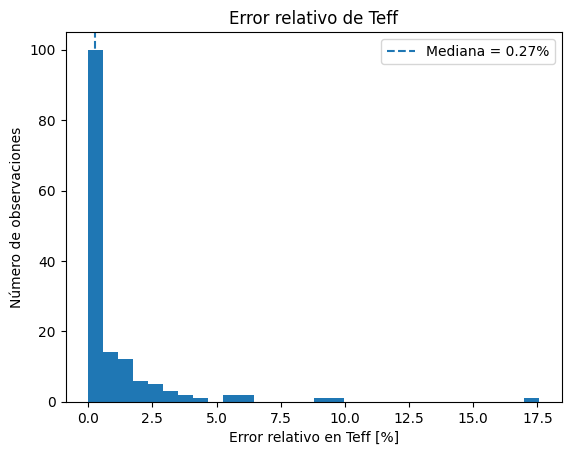

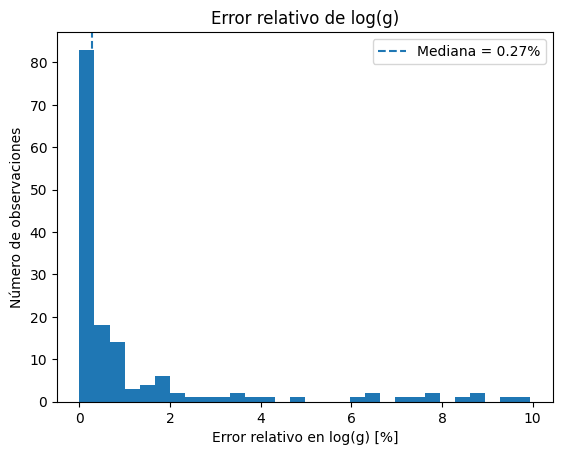

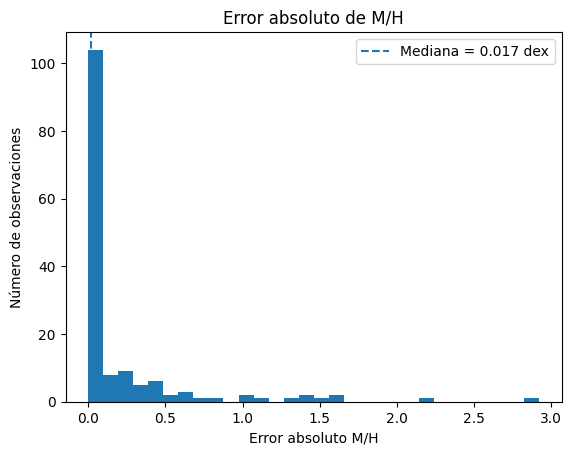

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5214.268590,4.659193,-0.839730,-142.739755,-0.151332,0.129299,142.739755,0.151332,0.129299,2.664542,3.145847
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5823.788007,4.710005,-1.125039,10.563699,0.002648,0.004798,10.563699,0.002648,0.004798,0.181718,0.056256
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6139.737527,4.695610,-1.160715,6143.157177,4.692623,-1.156016,3.419651,-0.002987,0.004699,3.419651,0.002987,0.004699,0.055697,0.063603
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6042.269395,4.167486,-0.687873,6033.668945,4.165500,-0.689000,-8.600449,-0.001986,-0.001127,8.600449,0.001986,0.001127,0.142338,0.047659
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6037.687771,4.298310,-0.610908,6032.771879,4.297565,-0.608763,-4.915893,-0.000745,0.002146,4.915893,0.000745,0.002146,0.081420,0.017329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,839,1563780142022633856,6524.167969,4.2145,-0.4674,6598.880164,4.310636,-0.489915,6547.616551,4.269460,-0.475265,-51.263613,-0.041176,0.014649,51.263613,0.041176,0.014649,0.776853,0.955224
146,327,1410023851879234688,6045.990234,4.5539,-1.1586,6046.810000,4.555778,-1.158566,6080.666555,4.598771,-1.200786,33.856555,0.042992,-0.042220,33.856555,0.042992,0.042220,0.559908,0.943691
147,1687,1314845963554562048,3131.839844,4.9757,0.0187,3878.044981,5.495160,-1.525130,3835.407856,5.071712,-0.914345,-42.637125,-0.423448,0.610785,42.637125,0.423448,0.610785,1.099449,7.705839
148,367,1665180059273240192,6108.652344,4.7004,-2.0908,6108.809248,4.704026,-2.337098,6109.970319,4.704225,-2.334926,1.161070,0.000199,0.002171,1.161070,0.000199,0.002171,0.019006,0.004237


In [41]:
error_3_df = analyze_ispec_errors(results_3_df)
display(error_3_df)